# Simple CNN Baseline

## Imports

In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
device = torch.device("cpu")
print("Using device:", device)

PyTorch: 2.9.0+cu128
Using device: cpu


## Load CSV and Image Paths

In [3]:
train_df = pd.read_csv("../data/raw/train.csv")
image_dir = "../data/raw/train_images/"

train_df.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


## Dataset Class

In [4]:
from torchvision import transforms

simple_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

class SimpleAPTOSDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_id = self.df.loc[idx, 'id_code']
        label  = int(self.df.loc[idx, 'diagnosis'])
        path = os.path.join(self.img_dir, f"{img_id}.png")

        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

## Train/Validation Split

In [5]:
train_df_, val_df = train_test_split(
    train_df, test_size=0.20, stratify=train_df['diagnosis'], random_state=42
)

train_dataset = SimpleAPTOSDataset(train_df_, image_dir, simple_transform)
val_dataset   = SimpleAPTOSDataset(val_df, image_dir, simple_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

len(train_loader), len(val_loader)

(92, 23)

## SimpleCNN

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 5)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)
        return self.fc(x)

model = SimpleCNN().to(device)
model

SimpleCNN(
  (conv): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=16384, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=5, bias=True)
  )
)

## Loss, Optimizer

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

## Training Loop

In [8]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)


def eval_epoch(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total

In [9]:
EPOCHS = 5
best_acc = 0

for epoch in range(1, EPOCHS+1):
    train_loss = train_epoch(model, train_loader)
    val_loss, val_acc = eval_epoch(model, val_loader)

    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1/5
Train Loss: 0.9845 | Val Loss: 0.8438 | Val Acc: 0.6917
Epoch 2/5
Train Loss: 0.8307 | Val Loss: 0.8148 | Val Acc: 0.7012
Epoch 3/5
Train Loss: 0.7779 | Val Loss: 0.7905 | Val Acc: 0.7149
Epoch 4/5
Train Loss: 0.7625 | Val Loss: 0.7964 | Val Acc: 0.7231
Epoch 5/5
Train Loss: 0.7370 | Val Loss: 0.8209 | Val Acc: 0.7067


## Evaluation

In [10]:
y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        outputs = model(imgs.to(device))
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.96      0.90       361
           1       0.00      0.00      0.00        74
           2       0.54      0.84      0.65       200
           3       0.50      0.13      0.20        39
           4       0.00      0.00      0.00        59

    accuracy                           0.71       733
   macro avg       0.38      0.39      0.35       733
weighted avg       0.59      0.71      0.63       733



/home/myid/rm98243/miniconda3/envs/aptos-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/myid/rm98243/miniconda3/envs/aptos-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/myid/rm98243/miniconda3/envs/aptos-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

Running Inference: 100%|██████████| 23/23 [00:56<00:00,  2.44s/it]

===== Simple CNN Metrics =====
Accuracy:            0.7067
Precision (macro):   0.5164
Recall  (macro):     0.3958
F1-score (macro):    0.3638
Balanced Accuracy:   0.3958

Classification Report:

              precision    recall  f1-score   support

           0     0.9011    0.9086    0.9048       361
           1     0.6667    0.0270    0.0519        74
           2     0.5140    0.9150    0.6583       200
           3     0.5000    0.1282    0.2041        39
           4     0.0000    0.0000    0.0000        59

    accuracy                         0.7067       733
   macro avg     0.5164    0.3958    0.3638       733
weighted avg     0.6780    0.7067    0.6413       733




/home/myid/rm98243/miniconda3/envs/aptos-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/myid/rm98243/miniconda3/envs/aptos-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/myid/rm98243/miniconda3/envs/aptos-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

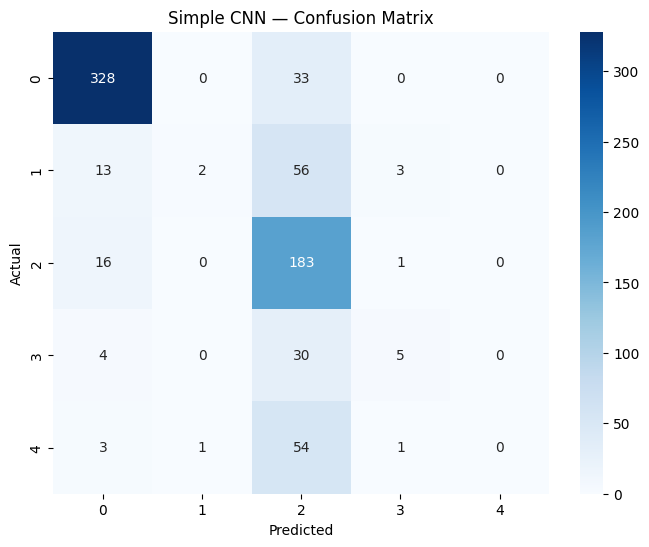

In [10]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, balanced_accuracy_score, confusion_matrix, classification_report
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ------------------------------
# Run Inference
# ------------------------------
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc="Running Inference"):
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ------------------------------
# Metrics
# ------------------------------
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec  = recall_score(y_true, y_pred, average='macro')
f1   = f1_score(y_true, y_pred, average='macro')
bacc = balanced_accuracy_score(y_true, y_pred)

print("===== Simple CNN Metrics =====")
print(f"Accuracy:            {acc:.4f}")
print(f"Precision (macro):   {prec:.4f}")
print(f"Recall  (macro):     {rec:.4f}")
print(f"F1-score (macro):    {f1:.4f}")
print(f"Balanced Accuracy:   {bacc:.4f}")
print("=====================================\n")

# Full Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, digits=4))

# ------------------------------
# Confusion Matrix
# ------------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2,3,4],
            yticklabels=[0,1,2,3,4])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Simple CNN — Confusion Matrix")
plt.show()

## Confusion Matrix

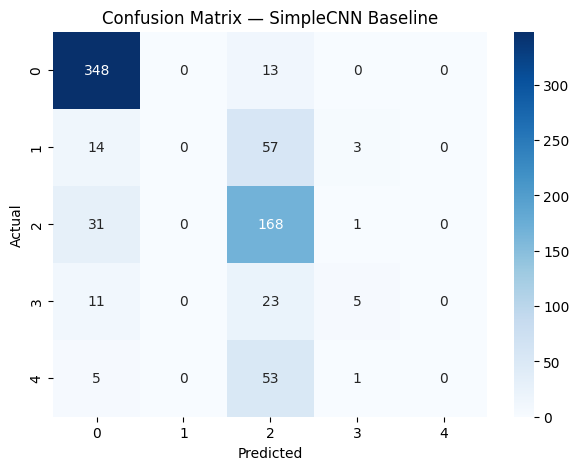

In [11]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — SimpleCNN Baseline")
plt.show()